In [3]:
# Подготовка: подключаем библиотеки и читаем CSV рядом с ноутбуком.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

df = pd.read_csv('cyber_statistics_practice.csv', parse_dates=['timestamp'])
print('Число строк:', len(df))
print('Число столбцов:', len(df.columns))

display(df.drop(columns=['is_malicious', 'attack_type']).head())

Число строк: 3200
Число столбцов: 15


,event_id,timestamp,period,source_ip,destination_service,user_role,request_method,requests_per_min,payload_size_bytes,response_time_ms,cpu_load_percent,source_port,severity_level
0,EVT-00001,2026-03-16 08:00:00,baseline,10.0.13.110,web,user,POST,14,48.60,55.75,36.08,64190,Medium
1,EVT-00002,2026-03-16 08:00:15,baseline,10.0.2.63,web,user,POST,15,4.60,24.99,42.50,53846,Low
2,EVT-00003,2026-03-16 08:00:30,baseline,10.0.18.36,api,user,PUT,16,30.22,62.13,44.94,51418,Low
3,EVT-00004,2026-03-16 08:00:45,baseline,10.0.5.130,files,user,GET,12,32.26,0.39,38.95,57883,Low
4,EVT-00005,2026-03-16 08:01:00,baseline,10.0.8.46,web,user,PUT,18,15.45,99.70,35.37,62599,Low


In [ ]:
# 1.1. Проверяем типы, пропуски и повторы.
print('Типы столбцов:')
display(df.dtypes.to_frame(name='тип'))

print('Пропуски в каждом столбце:')
display(df.isna().sum().to_frame(name='пропусков'))

print('Повторяющиеся строки:', df.duplicated().sum())
print('Повторяющиеся event_id:', df['event_id'].duplicated().sum())
print('События по периодам:')
display(df['period'].value_counts().to_frame(name='число событий'))

Типы столбцов:


,тип
event_id,str
timestamp,datetime64[us]
period,str
source_ip,str
destination_service,str
user_role,str
request_method,str
requests_per_min,int64
payload_size_bytes,float64
response_time_ms,float64


Пропуски в каждом столбце:


,пропусков
event_id,0
timestamp,0
period,0
source_ip,0
destination_service,0
user_role,0
request_method,0
requests_per_min,0
payload_size_bytes,0
response_time_ms,0


Повторяющиеся строки: 0
Повторяющиеся event_id: 0
События по периодам:


,число событий
period,
baseline,2400
investigation,800


In [5]:
# 1.2. Заполняем таблицу типов признаков.
# Тип в pandas и статистический смысл признака могут различаться.
feature_types = pd.DataFrame({
    'Признак': ['request_method', 'severity_level', 'requests_per_min',
                'response_time_ms', 'source_port', 'is_malicious'],
    'Вид': ['качественный', 'качественный', 'количественный',
            'количественный', 'числовой код', 'качественный'],
    'Шкала': ['номинальная', 'порядковая', 'дискретная',
              'непрерывная', 'дискретный номер', 'номинальная']
})
display(feature_types)

,Признак,Вид,Шкала
0,request_method,качественный,номинальная
1,severity_level,качественный,порядковая
2,requests_per_min,количественный,дискретная
3,response_time_ms,количественный,непрерывная
4,source_port,числовой код,дискретный номер
5,is_malicious,качественный,номинальная


In [ ]:
# 1.3. Преобразуем номинальные и порядковый признаки.
df['user_role'] = df['user_role'].astype('category')
df['request_method'] = df['request_method'].astype('category')
df['destination_service'] = df['destination_service'].astype('category')

# Для severity_level создается порядок категорий.
severity_order = ['Low', 'Medium', 'High', 'Critical']
df['severity_level'] = pd.Categorical(
    df['severity_level'], categories=severity_order, ordered=True
)

# Создаём выборки после преобразования, чтобы типы сохранились в обеих.
baseline = df[df['period'] == 'baseline'].copy()
investigation = df[df['period'] == 'investigation'].copy()
display(df.dtypes.to_frame(name='тип после преобразования'))

,тип после преобразования
event_id,str
timestamp,datetime64[us]
period,str
source_ip,str
destination_service,category
user_role,category
request_method,category
requests_per_min,int64
payload_size_bytes,float64
response_time_ms,float64


### Вывод 1

В данных 3200 событий: 2400 в `baseline` и 800 в `investigation`. Пропусков и повторов нет. `is_malicious` хранится как 0/1, но это обозначение двух классов, а не измеряемое число. В лекции `source_port` рассматривается как дискретный числовой признак; по смыслу это номер порта, поэтому среднее арифметическое портов само по себе не описывает активность. Уровни `severity_level` имеют естественный порядок, а методы запросов - нет.

In [ ]:
# 2.1. Таблица частот, PMF и ECDF для числа запросов в baseline.
counts = baseline['requests_per_min'].value_counts().sort_index()
request_table = pd.DataFrame({'Абсолютная частота': counts})
request_table['PMF'] = counts / len(baseline)

# В лекции ECDF определена как P(X < x).
# cumsum() даёт P(X <= x), поэтому сдвигаем результат на одну строку.
request_table['ECDF: P(X < x)'] = request_table['PMF'].cumsum().shift(1).fillna(0)

# Последняя строка показывает, что после максимума накопленная доля равна 1.
last_value = request_table.index.max()
request_table.loc[last_value + 1] = [0, 0, 1]
request_table.index.name = 'requests_per_min'
display(request_table)

,Абсолютная частота,PMF,ECDF: P(X < x)
requests_per_min,,,
3,1,0.000417,0.000000
4,2,0.000833,0.000417
5,5,0.002083,0.001250
6,9,0.003750,0.003333
7,24,0.010000,0.007083
8,52,0.021667,0.017083
9,89,0.037083,0.038750
10,136,0.056667,0.075833
11,163,0.067917,0.132500


In [ ]:
# 2.2. Делим время ответа baseline на 12 интервалов.
intervals = pd.cut(baseline['response_time_ms'], bins=12)
interval_counts = intervals.value_counts(sort=False)

response_table = pd.DataFrame({'Абсолютная частота': interval_counts})
response_table['Относительная частота'] = interval_counts / len(baseline)
response_table.index.name = 'Интервал времени ответа, мс'
display(response_table)

,Абсолютная частота,Относительная частота
"Интервал времени ответа, мс",,
"(-0.359, 30.766]",1145,0.477083
"(30.766, 61.522]",591,0.246250
"(61.522, 92.278]",277,0.115417
"(92.278, 123.033]",189,0.078750
"(123.033, 153.789]",95,0.039583
"(153.789, 184.545]",41,0.017083
"(184.545, 215.301]",34,0.014167
"(215.301, 246.057]",14,0.005833
"(246.057, 276.812]",4,0.001667


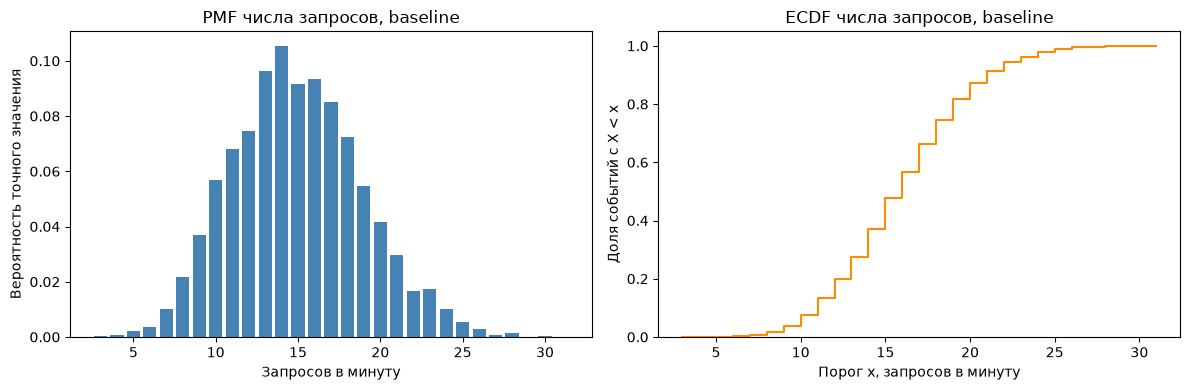

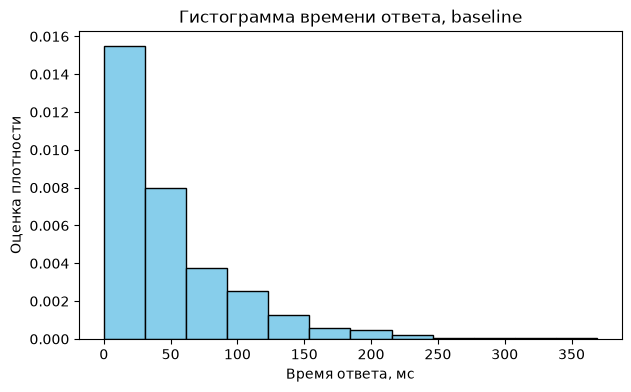

In [ ]:
# 2.3. Рисуем PMF, ECDF и гистограмму.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(request_table.index, request_table['PMF'], color='steelblue')
plt.title('PMF числа запросов, baseline')
plt.xlabel('Запросов в минуту')
plt.ylabel('Вероятность точного значения')

plt.subplot(1, 2, 2)
plt.step(request_table.index, request_table['ECDF: P(X < x)'],
         where='post', color='darkorange')
plt.title('ECDF числа запросов, baseline')
plt.xlabel('Порог x, запросов в минуту')
plt.ylabel('Доля событий с X < x')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Для непрерывного признака гистограмма приближает плотность.
plt.figure(figsize=(7, 4))
plt.hist(baseline['response_time_ms'], bins=12, density=True,
         color='skyblue', edgecolor='black')
plt.title('Гистограмма времени ответа, baseline')
plt.xlabel('Время ответа, мс')
plt.ylabel('Оценка плотности')
plt.show()

,Абсолютная частота,Доля
request_method,,
GET,1436,0.598333
POST,491,0.204583
DELETE,243,0.101250
PUT,230,0.095833


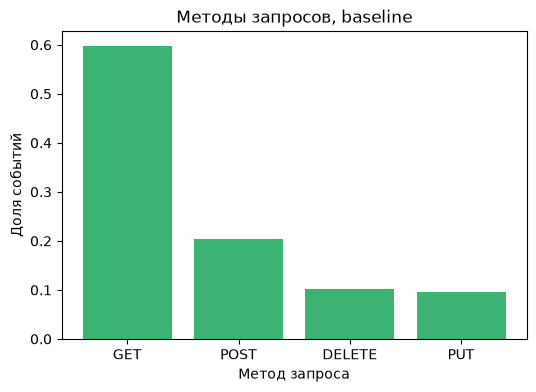

In [ ]:
# 2.4. Частоты категорий метода запроса.
method_counts = baseline['request_method'].value_counts()
method_table = pd.DataFrame({'Абсолютная частота': method_counts})
method_table['Доля'] = method_counts / len(baseline)
display(method_table)

plt.figure(figsize=(6, 4))
plt.bar(method_table.index, method_table['Доля'], color='mediumseagreen')
plt.title('Методы запросов, baseline')
plt.xlabel('Метод запроса')
plt.ylabel('Доля событий')
plt.show()

### Вывод 2

Число запросов - дискретный признак: PMF показывает долю событий с конкретным числом запросов. Гистограмма времени ответа показывает распределение непрерывного признака; при `density=True` площадь её столбцов равна единице, а высота столбца не является вероятностью отдельного значения. ECDF в обозначении лекции показывает долю событий, у которых число запросов строго меньше порога `x`; поэтому накопленная сумма в таблице сдвинута на одну строку. Для номинального `request_method` подходят частоты и столбчатая диаграмма.

In [ ]:
# 3.1. Функция для числовых характеристик одного столбца.
def descriptive_stats(values):
    mean_value = values.mean()
    median_value = values.median()
    std_value = values.std()

    # MAD - медиана абсолютных отклонений от медианы.
    mad_value = (values - median_value).abs().median()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    return pd.Series({
        'mean': mean_value, 'median': median_value, 'std': std_value,
        'MAD': mad_value, 'Q1': q1, 'Q3': q3, 'IQR': iqr
    })

In [ ]:
# 3.2. Применяем одну и ту же функцию к обоим периодам.
columns = ['cpu_load_percent', 'response_time_ms', 'payload_size_bytes']

baseline_stats = baseline[columns].apply(descriptive_stats)
investigation_stats = investigation[columns].apply(descriptive_stats)

print('Базовая линия:')
display(baseline_stats.round(2))
print('Окно расследования:')
display(investigation_stats.round(2))

Базовая линия:


,cpu_load_percent,response_time_ms,payload_size_bytes
mean,34.81,48.93,40.49
median,34.92,32.94,21.18
std,7.97,49.74,66.98
MAD,5.38,23.52,14.11
Q1,29.30,12.94,9.29
Q3,40.18,67.95,46.43
IQR,10.88,55.00,37.14


Окно расследования:


,cpu_load_percent,response_time_ms,payload_size_bytes
mean,49.17,69.12,562.25
median,44.92,41.14,17.44
std,18.36,89.83,1576.34
MAD,9.72,31.43,11.37
Q1,36.34,13.42,8.80
Q3,55.89,89.54,49.20
IQR,19.55,76.12,40.40


In [ ]:
# 3.3. Порог Q95 по baseline методом higher.
request_q95 = baseline['requests_per_min'].quantile(0.95, interpolation='higher')
print('Q95 числа запросов по baseline:', request_q95)

Q95 числа запросов по baseline: 22


### Вывод 3

Наиболее сильно среднее реагирует у `payload_size_bytes`: оно выросло с 40,49 до 562,25, хотя медиана снизилась с 21,18 до 17,45. Среднее время ответа выросло на 20,19 мс при росте медианы лишь на 8,21 мс; для CPU различие меньше. Это признак правого хвоста и отдельных крупных значений. MAD и IQR устойчивее стандартного отклонения к выбросам, так как опираются на медиану и квартили. Q95 `requests_per_min` по базовой линии методом `higher` равен 22.

Среднее CPU: 34.81
Стандартное отклонение: 7.96
p-value критерия Д'Агостино: 0.8172


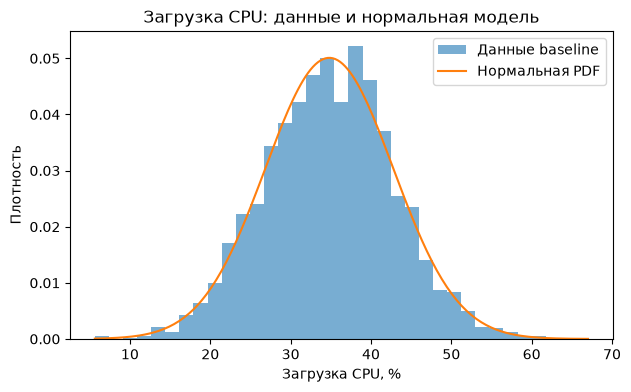

In [ ]:
# 4.1. Нормальная модель для загрузки CPU в baseline.
cpu = baseline['cpu_load_percent']
cpu_mean = cpu.mean()
cpu_std = cpu.std(ddof=0)
cpu_test = stats.normaltest(cpu)

print('Среднее CPU:', round(cpu_mean, 2))
print('Стандартное отклонение:', round(cpu_std, 2))
print("p-value критерия Д'Агостино:", round(cpu_test.pvalue, 4))

x_cpu = np.linspace(cpu.min(), cpu.max(), 200)
plt.figure(figsize=(7, 4))
plt.hist(cpu, bins=35, density=True, alpha=0.6, label='Данные baseline')
plt.plot(x_cpu, stats.norm.pdf(x_cpu, cpu_mean, cpu_std),
         label='Нормальная PDF')
plt.title('Загрузка CPU: данные и нормальная модель')
plt.xlabel('Загрузка CPU, %')
plt.ylabel('Плотность')
plt.legend()
plt.show()

Среднее ln(X): 3.02
Стандартное отклонение ln(X): 1.17
p-value нормальности ln(X): 0.7491


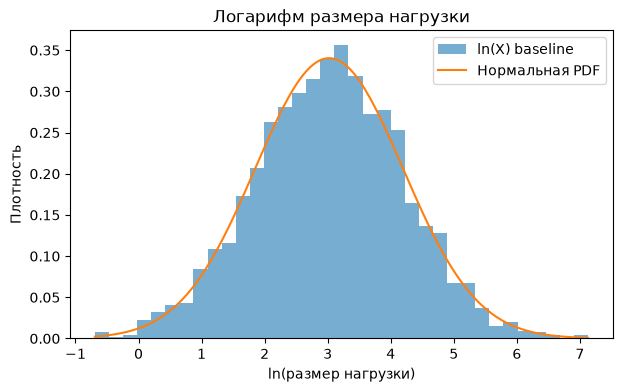

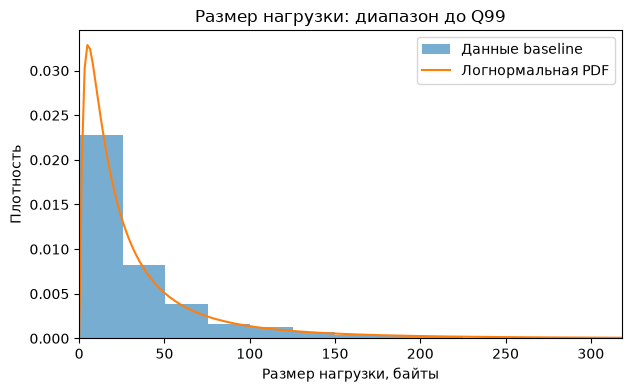

In [ ]:
# 4.2. Логнормальная модель для размера нагрузки.
payload = baseline['payload_size_bytes']
log_payload = np.log(payload)
log_mean = log_payload.mean()
log_std = log_payload.std(ddof=0)
log_test = stats.normaltest(log_payload)

print('Среднее ln(X):', round(log_mean, 2))
print('Стандартное отклонение ln(X):', round(log_std, 2))
print('p-value нормальности ln(X):', round(log_test.pvalue, 4))

# Сначала смотрим, похож ли логарифм на нормальное распределение.
x_log = np.linspace(log_payload.min(), log_payload.max(), 200)
plt.figure(figsize=(7, 4))
plt.hist(log_payload, bins=35, density=True, alpha=0.6, label='ln(X) baseline')
plt.plot(x_log, stats.norm.pdf(x_log, log_mean, log_std),
         label='Нормальная PDF')
plt.title('Логарифм размера нагрузки')
plt.xlabel('ln(размер нагрузки)')
plt.ylabel('Плотность')
plt.legend()
plt.show()

# Затем сравниваем исходные значения с логнормальной моделью.
payload_q99 = payload.quantile(0.99)
x_payload = np.linspace(0.01, payload_q99, 200)
plt.figure(figsize=(7, 4))
plt.hist(payload, bins=50, density=True, alpha=0.6, label='Данные baseline')
plt.plot(x_payload, stats.lognorm.pdf(x_payload, log_std, 0, np.exp(log_mean)),
         label='Логнормальная PDF')
plt.xlim(0, payload_q99)
plt.title('Размер нагрузки: диапазон до Q99')
plt.xlabel('Размер нагрузки, байты')
plt.ylabel('Плотность')
plt.legend()
plt.show()

Оценка scale: 48.93
Диагностический K-S p-value: 0.12


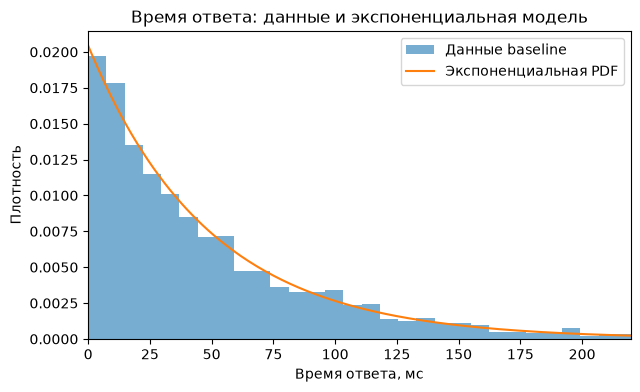

In [ ]:
# 4.3. Экспоненциальная модель времени ответа.
response = baseline['response_time_ms']
response_scale = response.mean()
response_test = stats.kstest(response, 'expon', args=(0, response_scale))

print('Оценка scale:', round(response_scale, 2))
print('Диагностический K-S p-value:', round(response_test.pvalue, 4))

x_response = np.linspace(0, response.quantile(0.99), 200)
plt.figure(figsize=(7, 4))
plt.hist(response, bins=50, density=True, alpha=0.6, label='Данные baseline')
plt.plot(x_response, stats.expon.pdf(x_response, 0, response_scale),
         label='Экспоненциальная PDF')
plt.xlim(0, response.quantile(0.99))
plt.title('Время ответа: данные и экспоненциальная модель')
plt.xlabel('Время ответа, мс')
plt.ylabel('Плотность')
plt.legend()
plt.show()

Оценка λ: 14.95
Дисперсия / среднее: 1.037


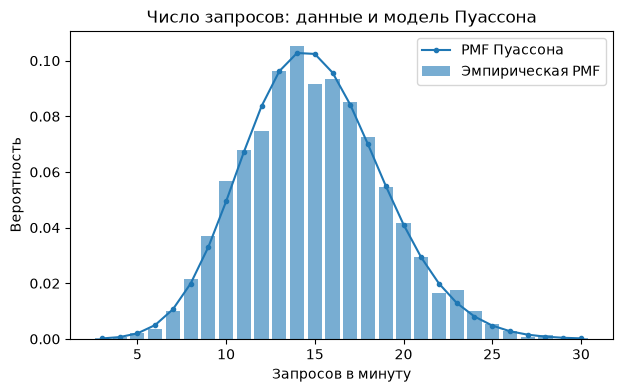

In [ ]:
# 4.4. Модель Пуассона для числа запросов.
poisson_lambda = baseline['requests_per_min'].mean()
request_variance = baseline['requests_per_min'].var()
observed_pmf = baseline['requests_per_min'].value_counts(normalize=True).sort_index()
x_requests = np.arange(observed_pmf.index.min(), observed_pmf.index.max() + 1)

print('Оценка λ:', round(poisson_lambda, 2))
print('Дисперсия / среднее:', round(request_variance / poisson_lambda, 3))

plt.figure(figsize=(7, 4))
plt.bar(observed_pmf.index, observed_pmf, alpha=0.6, label='Эмпирическая PMF')
plt.plot(x_requests, stats.poisson.pmf(x_requests, poisson_lambda),
         marker='o', markersize=3, label='PMF Пуассона')
plt.title('Число запросов: данные и модель Пуассона')
plt.xlabel('Запросов в минуту')
plt.ylabel('Вероятность')
plt.legend()
plt.show()

Ожидаемая частота в каждом бине: 75.0
Нормированная энтропия: 0.998
χ²: 32.613
p-value χ²: 0.3875


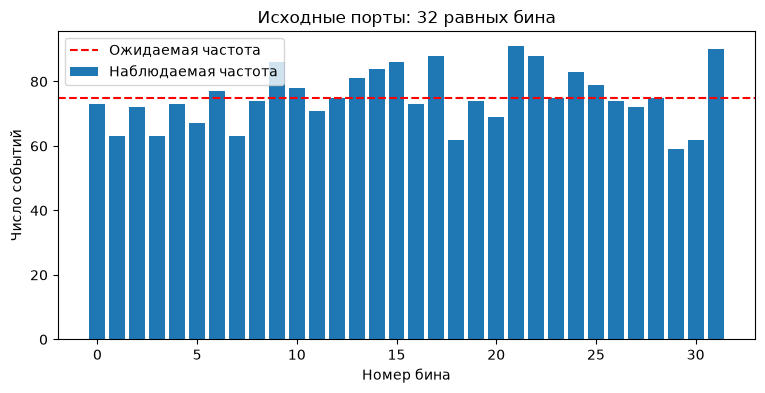

In [ ]:
# 4.5. Проверяем равномерность исходных портов по 32 бинам.
# Диапазон временных портов из лекции: 49152..65535.
port_edges_32 = np.linspace(49152, 65536, 33)
port_counts_32, edges = np.histogram(baseline['source_port'], bins=port_edges_32)
expected_count = len(baseline) / 32
port_test = stats.chisquare(port_counts_32, f_exp=np.full(32, expected_count))

# Энтропию считаем в битах, затем делим на максимум log2(32).
port_entropy_bits = stats.entropy(port_counts_32, base=2)
port_entropy_norm = port_entropy_bits / np.log2(32)

print('Ожидаемая частота в каждом бине:', expected_count)
print('Нормированная энтропия:', round(port_entropy_norm, 3))
print('χ²:', round(port_test.statistic, 3))
print('p-value χ²:', round(port_test.pvalue, 4))

plt.figure(figsize=(9, 4))
plt.bar(range(32), port_counts_32, label='Наблюдаемая частота')
plt.axhline(expected_count, color='red', linestyle='--',
            label='Ожидаемая частота')
plt.title('Исходные порты: 32 равных бина')
plt.xlabel('Номер бина')
plt.ylabel('Число событий')
plt.legend()
plt.show()

In [ ]:
# 4.6. Собираем результаты проверки моделей в одну таблицу.
# p-value не доказывает закон: вывод также учитывает форму графика.
models = pd.DataFrame({
    'Признак': ['cpu_load_percent', 'payload_size_bytes', 'response_time_ms',
                'requests_per_min', 'source_port'],
    'Закон': ['нормальный', 'логнормальный', 'экспоненциальный',
              'Пуассона', 'равномерный'],
    'Параметры': [f'μ={cpu_mean:.2f}, σ={cpu_std:.2f}',
                  f'μ_ln={log_mean:.2f}, σ_ln={log_std:.2f}',
                  f'scale={response_scale:.2f}',
                  f'λ={poisson_lambda:.2f}',
                  'порты 49152..65535'],
    'p-value': [f'{cpu_test.pvalue:.3g}', f'{log_test.pvalue:.3g}',
                f'{response_test.pvalue:.3g}', 'визуально',
                f'{port_test.pvalue:.3g}'],
    'Норм. энтропия': ['-', '-', '-', '-', f'{port_entropy_norm:.3f}'],
    'Вывод': ['график и тест согласуются', 'логарифм близок к нормальному',
              'приближение пригодно; K-S диагностический',
              'PMF и дисперсия близки к модели',
              'частоты бинов близки к равномерным']
})
display(models)

,Признак,Закон,Параметры,p-value,Норм. энтропия,Вывод
0,cpu_load_percent,нормальный,"μ=34.81, σ=7.96",0.817,-,график и тест согласуются
1,payload_size_bytes,логнормальный,"μ_ln=3.02, σ_ln=1.17",0.749,-,логарифм близок к нормальному
2,response_time_ms,экспоненциальный,scale=48.93,0.12,-,приближение пригодно; K-S диагностический
3,requests_per_min,Пуассона,λ=14.95,визуально,-,PMF и дисперсия близки к модели
4,source_port,равномерный,порты 49152..65535,0.387,0.998,частоты бинов близки к равномерным


### Вывод 4

Для базовой линии предложенные законы выглядят разумными приближениями: критерий Д'Агостино даёт p=0,817 для CPU и p=0,749 для логарифма нагрузки; диагностический K-S для времени ответа даёт p=0,120. Отношение дисперсии к среднему числа запросов равно примерно 1,04, что согласуется с моделью Пуассона. Для портов нормированная энтропия по 32 бинам равна 0,998, а χ² даёт p=0,387 при ожидаемой частоте 75 в каждом бине. Ни одно p-value не доказывает точный закон распределения. В K-S параметр `scale` оценён по тем же данным, поэтому его p-value используется лишь как диагностика.

In [ ]:
# 5.1. Сравниваем медиану и Q95 измеряемых признаков.
numeric_columns = ['requests_per_min', 'cpu_load_percent',
                   'response_time_ms', 'payload_size_bytes']

medians = df.groupby('period')[numeric_columns].median().T
q95 = df.groupby('period')[numeric_columns].quantile(0.95).T

print('Медианы:')
display(medians.round(2))
print('Q95:')
display(q95.round(2))

# Доля превышений порога из шага 3.3.
baseline_above = (baseline['requests_per_min'] > request_q95).mean() * 100
investigation_above = (investigation['requests_per_min'] > request_q95).mean() * 100
print('Выше базового Q95, baseline:', round(baseline_above, 2), '%')
print('Выше базового Q95, investigation:', round(investigation_above, 2), '%')

Медианы:


period,baseline,investigation
requests_per_min,15.00,20.00
cpu_load_percent,34.92,44.92
response_time_ms,32.94,41.14
payload_size_bytes,21.18,17.44


Q95:


period,baseline,investigation
requests_per_min,22.00,72.00
cpu_load_percent,47.71,86.17
response_time_ms,148.43,243.49
payload_size_bytes,134.81,4172.44


Выше базового Q95, baseline: 3.83 %
Выше базового Q95, investigation: 46.88 %


In [ ]:
# 5.2. Сравниваем методы запросов и уровни критичности.
method_percent = pd.crosstab(df['period'], df['request_method'],
                             normalize='index') * 100
severity_percent = pd.crosstab(df['period'], df['severity_level'],
                               normalize='index') * 100
severity_percent = severity_percent[severity_order]

print('Доли методов, %:')
display(method_percent.round(2))
print('Доли уровней критичности, %:')
display(severity_percent.round(2))

# Для порядковой критичности накопленная доля имеет смысл.
print('Накопленные доли критичности, %:')
display(severity_percent.cumsum(axis=1).round(2))

# Для номинальных методов считаем моду, VR и энтропию Шеннона в битах.
base_probs = baseline['request_method'].value_counts(normalize=True)
invest_probs = investigation['request_method'].value_counts(normalize=True)

method_metrics = pd.DataFrame({
    'Мода': [base_probs.idxmax(), invest_probs.idxmax()],
    'VR': [1 - base_probs.max(), 1 - invest_probs.max()],
    'Энтропия, бит': [stats.entropy(base_probs, base=2),
                       stats.entropy(invest_probs, base=2)]
}, index=['baseline', 'investigation'])
display(method_metrics.round(3))

Доли методов, %:


request_method,DELETE,GET,POST,PUT
period,,,,
baseline,10.12,59.83,20.46,9.58
investigation,3.38,54.00,35.25,7.38


Доли уровней критичности, %:


severity_level,Low,Medium,High,Critical
period,,,,
baseline,61.00,31.75,6.29,0.96
investigation,24.88,17.00,33.62,24.50


Накопленные доли критичности, %:


severity_level,Low,Medium,High,Critical
period,,,,
baseline,61.00,92.75,99.04,100.0
investigation,24.88,41.88,75.50,100.0


,Мода,VR,"Энтропия, бит"
baseline,GET,0.402,1.570
investigation,GET,0.460,1.453


Нормированная энтропия baseline: 0.996
Нормированная энтропия investigation: 0.869


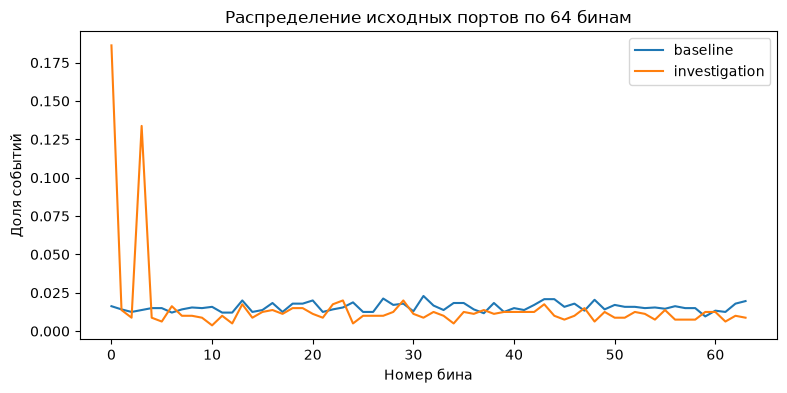

In [ ]:
# 5.3. Сравниваем энтропию исходных портов по 64 одинаковым бинам.
port_edges_64 = np.linspace(49152, 65536, 65)
base_ports, edges = np.histogram(baseline['source_port'], bins=port_edges_64)
invest_ports, edges = np.histogram(investigation['source_port'], bins=port_edges_64)

base_entropy = stats.entropy(base_ports, base=2) / np.log2(64)
invest_entropy = stats.entropy(invest_ports, base=2) / np.log2(64)

print('Нормированная энтропия baseline:', round(base_entropy, 3))
print('Нормированная энтропия investigation:', round(invest_entropy, 3))

# Сравниваем доли, так как в периодах разное число событий.
plt.figure(figsize=(9, 4))
plt.plot(range(64), base_ports / len(baseline), label='baseline')
plt.plot(range(64), invest_ports / len(investigation), label='investigation')
plt.title('Распределение исходных портов по 64 бинам')
plt.xlabel('Номер бина')
plt.ylabel('Доля событий')
plt.legend()
plt.show()

### 5.4. Признаки инцидента и гипотезы до просмотра меток

1. Медиана числа запросов выросла с 15 до 20, а Q95 - с 22 до 72; одновременно выросли верхние квантили загрузки CPU и времени ответа. Возможен DDoS или другая перегрузка сервиса.
2. Доля POST выросла с 20,46% до 35,25%, а доля High/Critical - с 7,25% до 58,13%. Следует проверить перебор учётных данных в сервисе авторизации.
3. Q95 размера нагрузки вырос со 134,81 до 4172,44 при снижении медианы. Возможны редкие крупные передачи данных.
4. Нормированная энтропия `source_port` снизилась с 0,996 до 0,869. Это повод проверить сканирование, но исходных портов недостаточно для его доказательства: нужны целевые порты.

Следующая ячейка впервые открывает метки `attack_type` и `is_malicious`.

In [ ]:
# 5.4. Только теперь проверяем гипотезы по меткам атак.
attack_counts = pd.crosstab(df['period'], df['attack_type'])
display(attack_counts)

# Смотрим типичное значение каждого измеряемого признака по типу атаки.
attack_medians = df.groupby('attack_type')[numeric_columns].median()
display(attack_medians.round(2))

# Проверяем связь атак с методом запроса и сервисом назначения.
attack_methods = pd.crosstab(df['attack_type'], df['request_method'],
                             normalize='index') * 100
attack_services = pd.crosstab(df['attack_type'], df['destination_service'],
                              normalize='index') * 100
display(attack_methods.round(1))
display(attack_services.round(1))

# Проверяем, как тип атаки связан с бинарной меткой.
display(pd.crosstab(df['attack_type'], df['is_malicious']))

attack_type,brute_force,ddos,exfiltration,normal,port_scan
period,,,,,
baseline,0,0,0,2400,0
investigation,100,140,120,300,140


,requests_per_min,cpu_load_percent,response_time_ms,payload_size_bytes
attack_type,,,,
brute_force,39.0,54.84,18.79,12.23
ddos,67.0,82.70,126.28,17.06
exfiltration,8.0,47.48,52.96,2890.07
normal,15.0,34.92,33.14,21.34
port_scan,30.0,43.38,15.40,8.27


request_method,DELETE,GET,POST,PUT
attack_type,,,,
brute_force,0.0,7.0,93.0,0.0
ddos,0.0,85.7,14.3,0.0
exfiltration,0.0,0.0,80.0,20.0
normal,10.0,59.3,20.9,9.8
port_scan,0.0,100.0,0.0,0.0


destination_service,api,auth,files,web
attack_type,,,,
brute_force,0.0,100.0,0.0,0.0
ddos,27.9,0.0,0.0,72.1
exfiltration,0.0,0.0,100.0,0.0
normal,30.6,20.2,12.2,37.0
port_scan,30.7,38.6,0.0,30.7


is_malicious,0,1
attack_type,,
brute_force,0,100
ddos,0,140
exfiltration,0,120
normal,2700,0
port_scan,0,140


### Вывод 5

В окне расследования мода метода осталась GET. VR вырос с 0,402 до 0,460, а энтропия методов снизилась примерно с 1,570 до 1,453 бит: VR зависит только от доли моды, энтропия учитывает все категории. После раскрытия меток обнаружены 140 событий `ddos`, 140 `port_scan`, 120 `exfiltration`, 100 `brute_force` и 300 `normal`. У DDoS медиана числа запросов равна 67, у эксфильтрации медиана нагрузки около 2890, а 93% событий `brute_force` используют POST и все связаны с `auth`. Наличие метки `port_scan` в учебном наборе не заменяет проверку целевых портов в реальной сети.

### Итоговая записка SOC

В окне расследования обнаружено заметное отклонение от базового профиля сетевых событий. Медиана частоты запросов выросла с 15 до 20 в минуту, Q95 - с 22 до 72, а доля High/Critical увеличилась с 7,25% до 58,13%. Верхний квантиль размера нагрузки вырос со 134,81 до 4172,44 при снижении медианы, что указывает на отдельные крупные передачи. Эти признаки согласуются с перегрузкой сервиса, перебором учётных данных и возможным выводом данных; последующая сверка с метками показывает также размеченные события сканирования портов. Для подтверждения механизма сканирования и оценки воздействия необходимы сведения о целевых портах, сетевых сессиях и ответах сервиса.